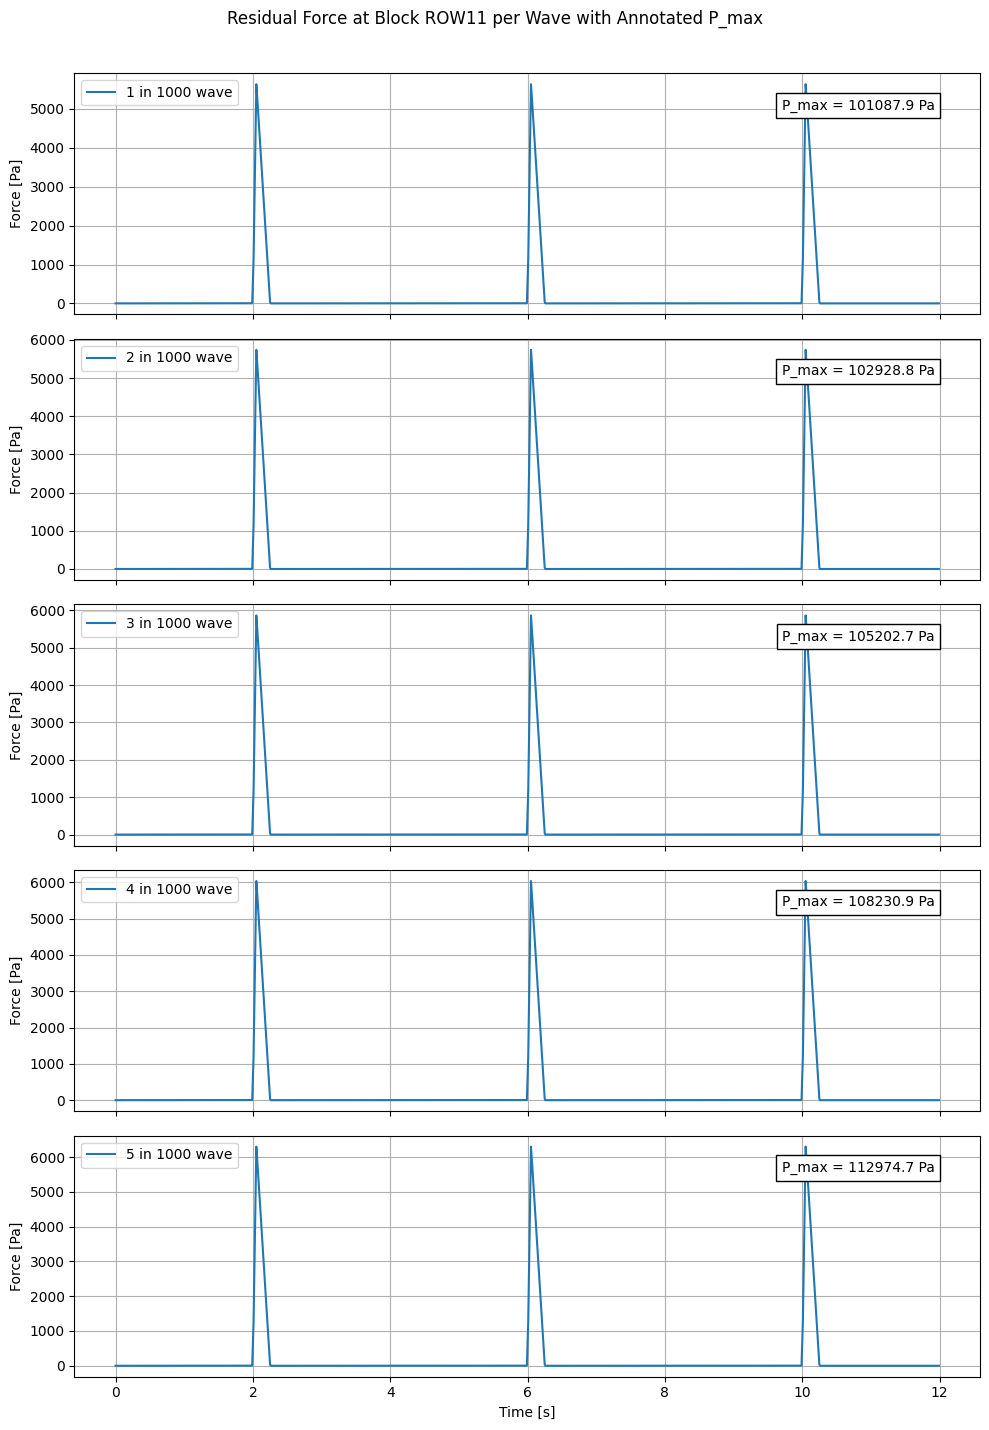

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- Parameters ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)

dx = 0.01
L = 10.0
x = np.arange(0, L + dx, dx)
N = len(x)
block_x_centers = np.linspace(2.0, 12.5, 22)

Hs = 1.0
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(5, 0, -1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Plot setup ---
fig, axs = plt.subplots(5, 1, figsize=(10, 15), sharex=True)

for i, H_wave in enumerate(wave_heights):
    wave_name = f"{i+1} in 1000 wave"

    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi_m_1_0 = tan_beta / np.sqrt(H_wave / L_m_1_0)
    denom = (xi_m_1_0 - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi_m_1_0 - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    wave_impact = np.piecewise(
        x,
        [x < 4, (x >= 4) & (x < 4.5), (x >= 4.5) & (x < 5.5), (x >= 5.5) & (x < 6), x >= 6],
        [
            0,
            lambda x: (x - 4) * (P_max / 0.5),
            P_max,
            lambda x: P_max - (x - 5.5) * (P_max / 0.5),
            0
        ]
    )

    b_vec = -wave_impact.copy()
    b_vec[0] = 0
    b_vec[-1] = 0

    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j]     = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = 1.0
    A[-1, -1] = 1.0

    phi_F = np.linalg.solve(A, b_vec)
    residual_force = phi_F - wave_impact

    residual_head_from_x = interp1d(x, residual_force, bounds_error=False, fill_value=0)
    block_heads_residual = residual_head_from_x(block_x_centers)

    tt = np.linspace(0, 4, 200)
    pulse_shape = np.zeros_like(tt)
    pulse_indices = (tt >= 2.0) & (tt <= 2.25)
    pulse_t = tt[pulse_indices] - 2.0
    pulse_shape[pulse_indices] = np.interp(pulse_t, [0, 0.05, 0.25], [0, 1, 0])
    residual_func = interp1d(tt, pulse_shape, kind='linear', fill_value=0, bounds_error=False)

    time_high_res = np.arange(0, 11.991, 0.01)
    row11_forces = []
    for t in time_high_res:
        t_mod = t % 4
        res_val = residual_func(t_mod)
        row11_force = np.round(block_heads_residual[10] * res_val, 5)
        row11_forces.append(row11_force)

    axs[i].plot(time_high_res, row11_forces, label=wave_name)
    axs[i].set_ylabel("Force [Pa]")
    axs[i].text(0.95, 0.85, f"P_max = {P_max:.1f} Pa", transform=axs[i].transAxes,
                ha='right', bbox=dict(facecolor='white', edgecolor='black'))
    axs[i].legend()
    axs[i].grid(True)

axs[-1].set_xlabel("Time [s]")
plt.suptitle("Residual Force at Block ROW11 per Wave with Annotated P_max")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


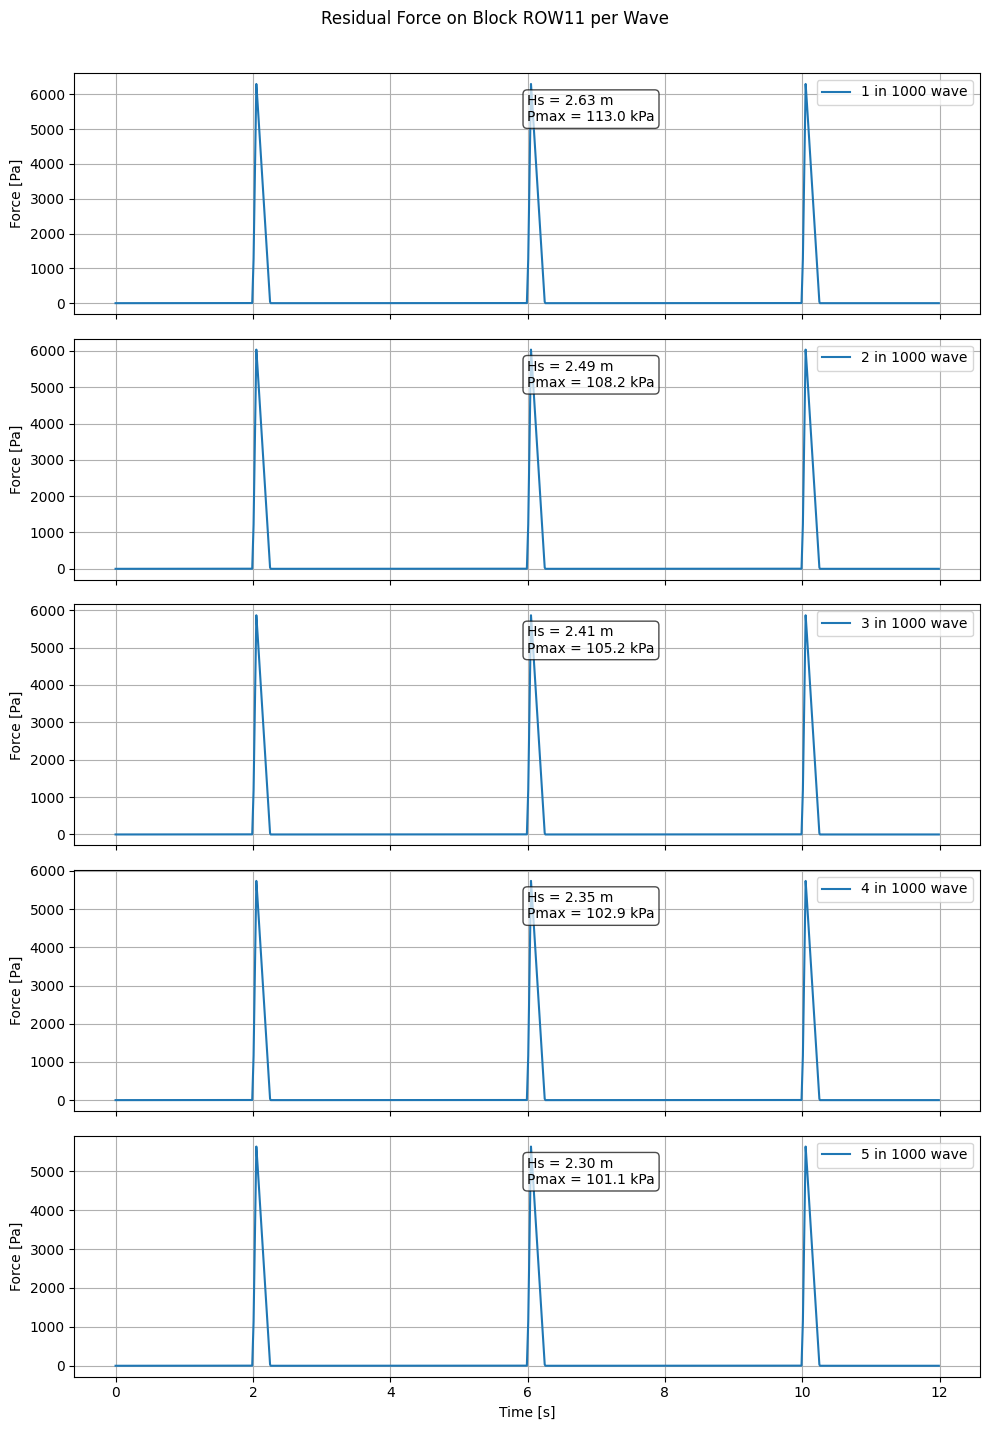

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
from scipy.interpolate import interp1d
import pandas as pd

# --- Setup ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)

dx = 0.01
L = 10.0
x = np.arange(0, L + dx, dx)
N = len(x)

x_start, y_start = 1.86, 6.05
block_width = 0.5
n_blocks = 22
angle_rad = np.arctan(tan_beta)
block_x_centers = np.linspace(2.0, 12.5, 22)

# --- Rayleigh wave generation for Hs = 1.0 ---
Hs_base = 1.0
sigma = Hs_base / np.sqrt(2)
exceed_probs = np.arange(5, 0, -1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Store results ---
dfs = {}
Hs_info = {}
Pmax_info = {}

for i, H_wave in enumerate(wave_heights):
    wave_name = f"{5 - i} in 1000 wave"
    Hs_info[wave_name] = H_wave

    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi_m_1_0 = tan_beta / np.sqrt(H_wave / L_m_1_0)
    denom = (xi_m_1_0 - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi_m_1_0 - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave
    Pmax_info[wave_name] = P_max

    wave_impact = np.piecewise(
        x,
        [x < 4, (x >= 4) & (x < 4.5), (x >= 4.5) & (x < 5.5), (x >= 5.5) & (x < 6), x >= 6],
        [
            0,
            lambda x: (x - 4) * (P_max / 0.5),
            P_max,
            lambda x: P_max - (x - 5.5) * (P_max / 0.5),
            0
        ]
    )

    b_vec = -wave_impact.copy()
    b_vec[0] = 0
    b_vec[-1] = 0

    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j]     = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = 1.0
    A[-1, -1] = 1.0

    phi_F = solve(A, b_vec)
    residual_force = phi_F - wave_impact

    residual_head_from_x = interp1d(x, residual_force, bounds_error=False, fill_value=0)
    block_heads_residual = residual_head_from_x(block_x_centers)

    # Pulse
    tt = np.linspace(0, 4, 200)
    pulse_shape = np.zeros_like(tt)
    pulse_indices = (tt >= 2.0) & (tt <= 2.25)
    pulse_t = tt[pulse_indices] - 2.0
    pulse_shape[pulse_indices] = np.interp(pulse_t, [0, 0.05, 0.25], [0, 1, 0])
    residual_func = interp1d(tt, pulse_shape, kind='linear', fill_value=0, bounds_error=False)

    time_high_res = np.arange(0, 11.991, 0.01)
    data = []
    for t in time_high_res:
        t_mod = t % 4
        res_val = residual_func(t_mod)
        forces = np.round(block_heads_residual * res_val, 5)
        data.append([round(t, 3)] + list(forces))

    columns = ["TIME"] + [f"ROW{j+1}" for j in range(n_blocks)]
    df = pd.DataFrame(data, columns=columns)
    dfs[wave_name] = df

# --- Plot residual force at ROW11 for each wave ---
fig, axs = plt.subplots(5, 1, figsize=(10, 15), sharex=True)

for i, (wave_name, df) in enumerate(sorted(dfs.items(), key=lambda x: int(x[0].split()[0]))):
    axs[i].plot(df["TIME"], df["ROW11"], label=wave_name)
    axs[i].set_ylabel("Force [Pa]")
    axs[i].legend()
    axs[i].grid(True)
    axs[i].text(0.5, 0.8, f"Hs = {Hs_info[wave_name]:.2f} m\nPmax = {Pmax_info[wave_name]/1000:.1f} kPa",
                transform=axs[i].transAxes, fontsize=10,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

axs[-1].set_xlabel("Time [s]")
plt.suptitle("Residual Force on Block ROW11 per Wave")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


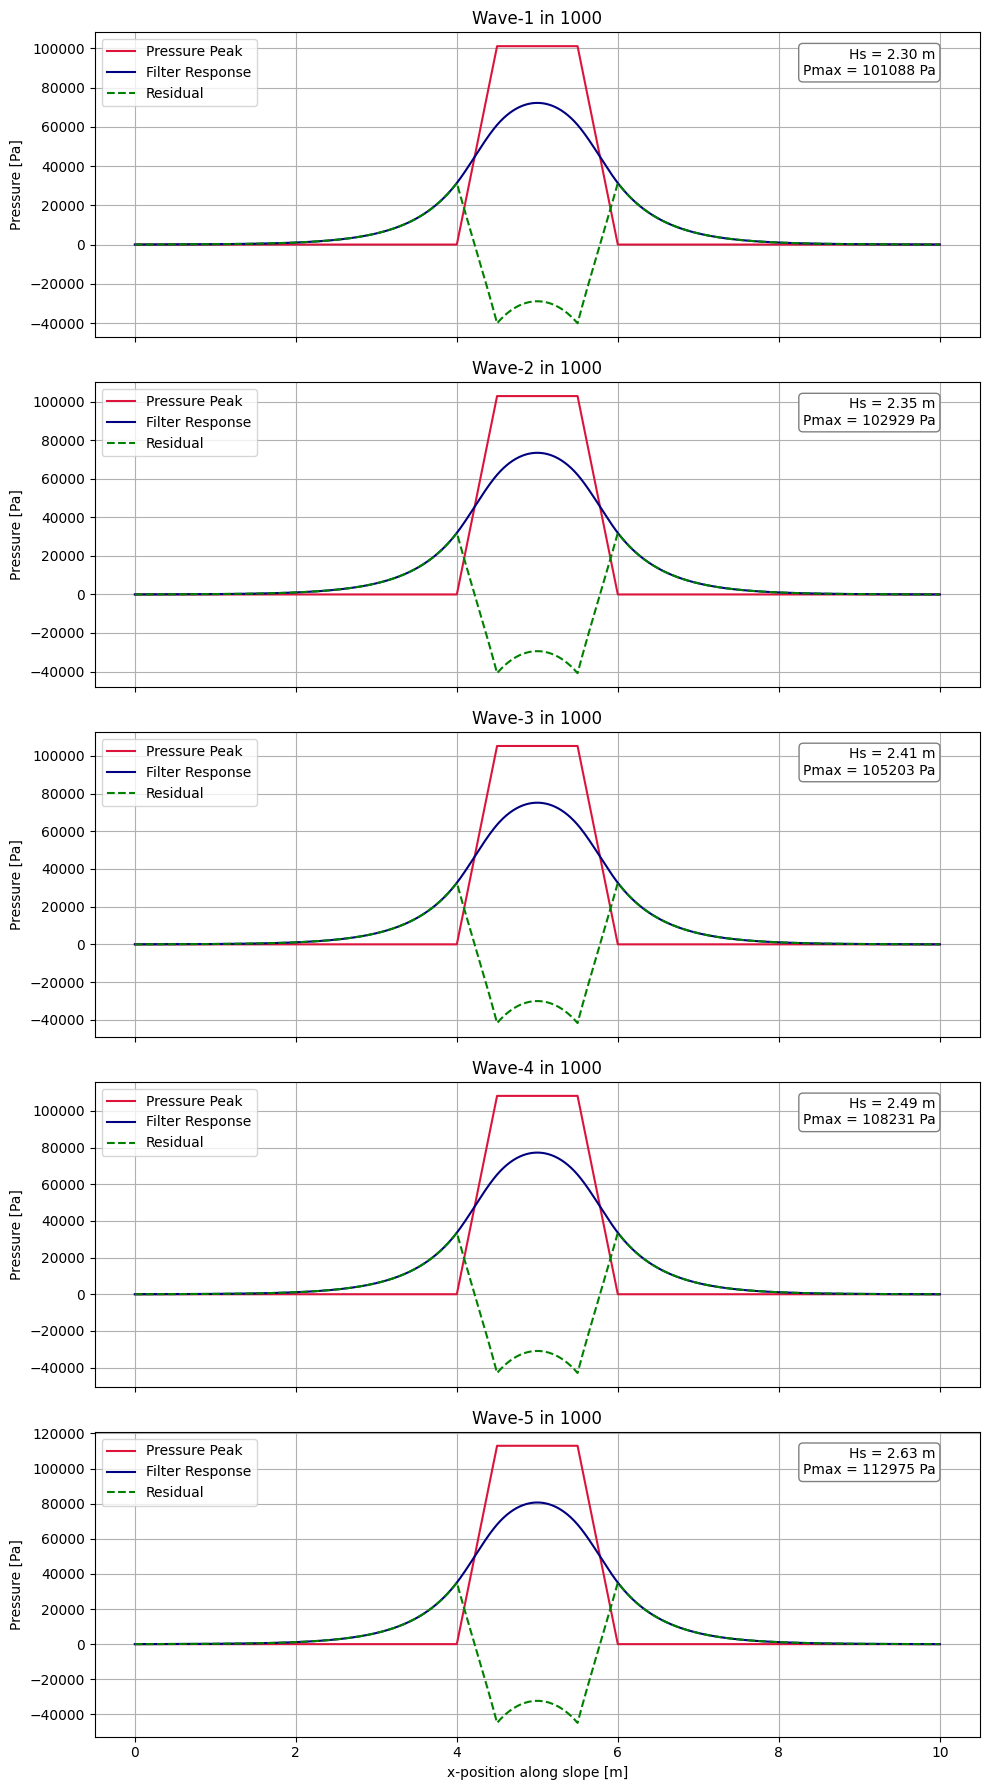

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
from scipy.interpolate import interp1d
import pandas as pd

# --- Setup ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)

dx = 0.01
L = 10.0
x = np.arange(0, L + dx, dx)
N = len(x)

# --- Rayleigh wave generation for Hs = 1.0 ---
Hs = 1.0
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(5, 0, -1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Store results ---
results = []

for i, H_wave in enumerate(wave_heights):
    wave_name = f"Wave-{i+1}_in_1000"

    # Wave physics
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi_m_1_0 = tan_beta / np.sqrt(H_wave / L_m_1_0)
    denom = (xi_m_1_0 - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi_m_1_0 - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    wave_impact = np.piecewise(
        x,
        [x < 4, (x >= 4) & (x < 4.5), (x >= 4.5) & (x < 5.5), (x >= 5.5) & (x < 6), x >= 6],
        [
            0,
            lambda x: (x - 4) * (P_max / 0.5),
            P_max,
            lambda x: P_max - (x - 5.5) * (P_max / 0.5),
            0
        ]
    )

    b_vec = -wave_impact.copy()
    b_vec[0] = 0
    b_vec[-1] = 0

    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j]     = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = 1.0
    A[-1, -1] = 1.0

    phi_F = solve(A, b_vec)
    residual_force = phi_F - wave_impact
    results.append((wave_name, x, wave_impact, phi_F, residual_force, H_wave, P_max))

# --- Plot wave impact, filter response, and residual for each wave ---
fig, axs = plt.subplots(5, 1, figsize=(10, 18), sharex=True)

for i, (wave_name, x_vals, impact, response, residual, H, P) in enumerate(results):
    axs[i].plot(x_vals, impact, label='Pressure Peak', color='crimson', linewidth=1.5)
    axs[i].plot(x_vals, response, label='Filter Response', color='navy', linewidth=1.5)
    axs[i].plot(x_vals, residual, label='Residual', color='green', linestyle='--')
    axs[i].text(0.95, 0.95, f'Hs = {H:.2f} m\nPmax = {P:.0f} Pa',
                transform=axs[i].transAxes, fontsize=10, ha='right', va='top',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))
    
    axs[i].set_ylabel("Pressure [Pa]")
    axs[i].legend()
    axs[i].grid(True)
    axs[i].set_title(wave_name.replace("_", " "))

axs[-1].set_xlabel("x-position along slope [m]")
plt.tight_layout()
plt.show()


[0.001 0.002 0.003 0.004 0.005]
[2.62826088 2.49291157 2.41021638 2.34977891 2.30180741]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 0. 0. 0.]


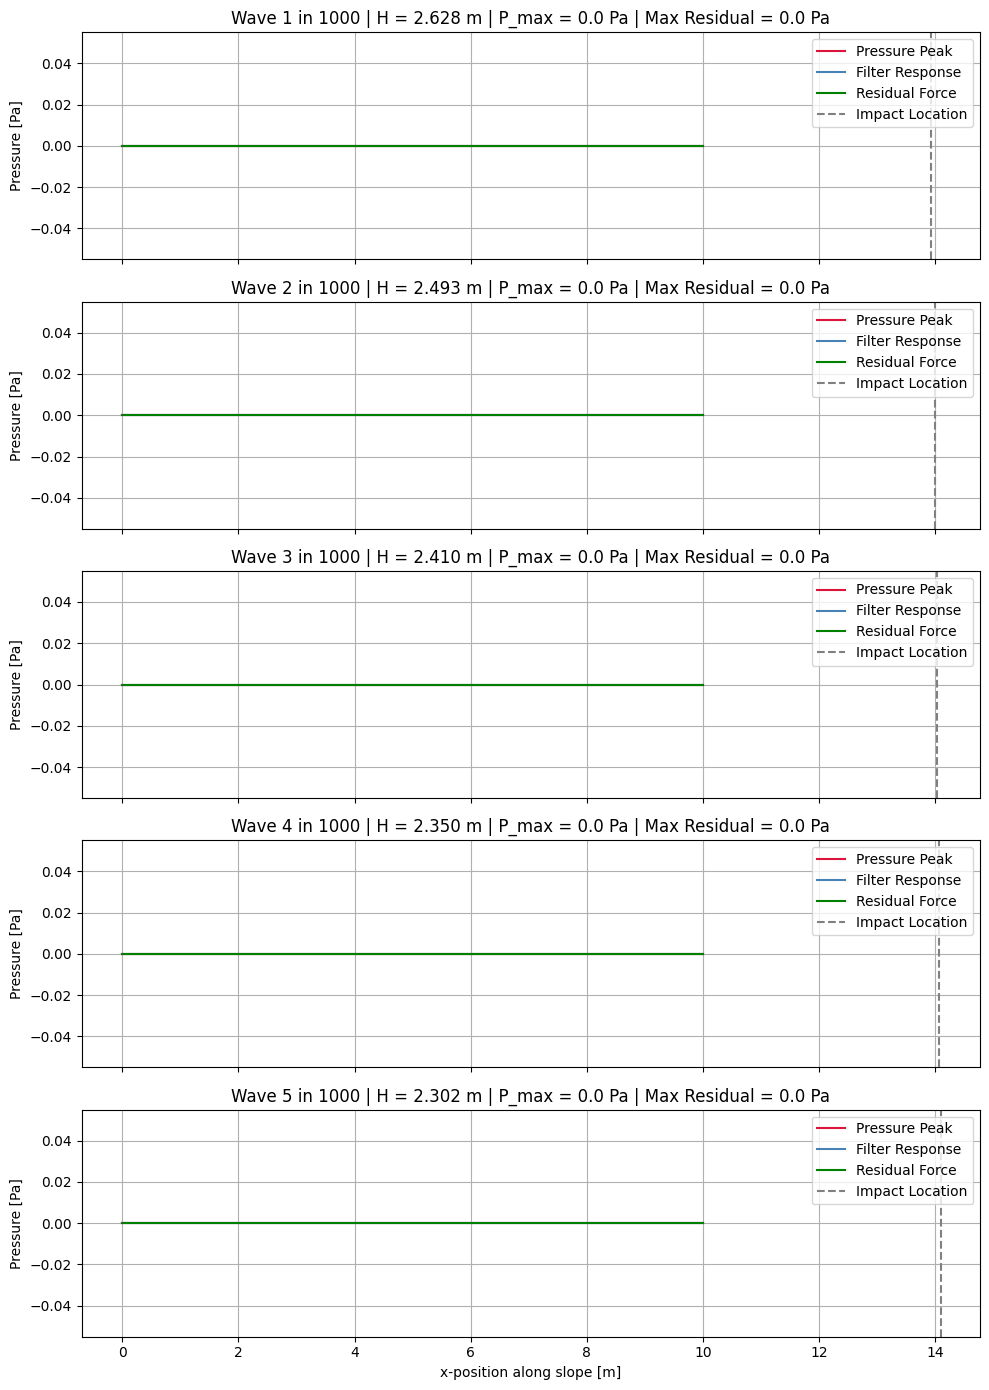

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
from scipy.interpolate import interp1d

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 5.7
dx = 0.01
x = np.arange(0, 10.0 + dx, dx)
N = len(x)

# --- Block locations (for info only) ---
block_x_centers = np.linspace(2.0, 12.5, 22)

# --- Generate wave heights (Rayleigh for Hs=1.0) ---
Hs = 1.0
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
print(exceed_probs)
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))
print(wave_heights)

# --- Storage for plots ---
fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)
    
    print(p_vals)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    # Plot
    axs[i].plot(x, p_vals, label="Pressure Peak", color="crimson")
    axs[i].plot(x, phi_F, label="Filter Response", color="steelblue")
    axs[i].plot(x, residual, label="Residual Force", color="green")
    axs[i].axvline(x=x_center, color='gray', linestyle='--', label='Impact Location')

    axs[i].set_ylabel("Pressure [Pa]")
    axs[i].legend(loc="upper right")
    axs[i].grid(True)
    axs[i].set_title(f"Wave {i+1} in 1000 | H = {H_wave:.3f} m | P_max = {np.max(p_vals):.1f} Pa | Max Residual = {np.max(residual):.1f} Pa")

axs[-1].set_xlabel("x-position along slope [m]")
plt.tight_layout()
plt.show()


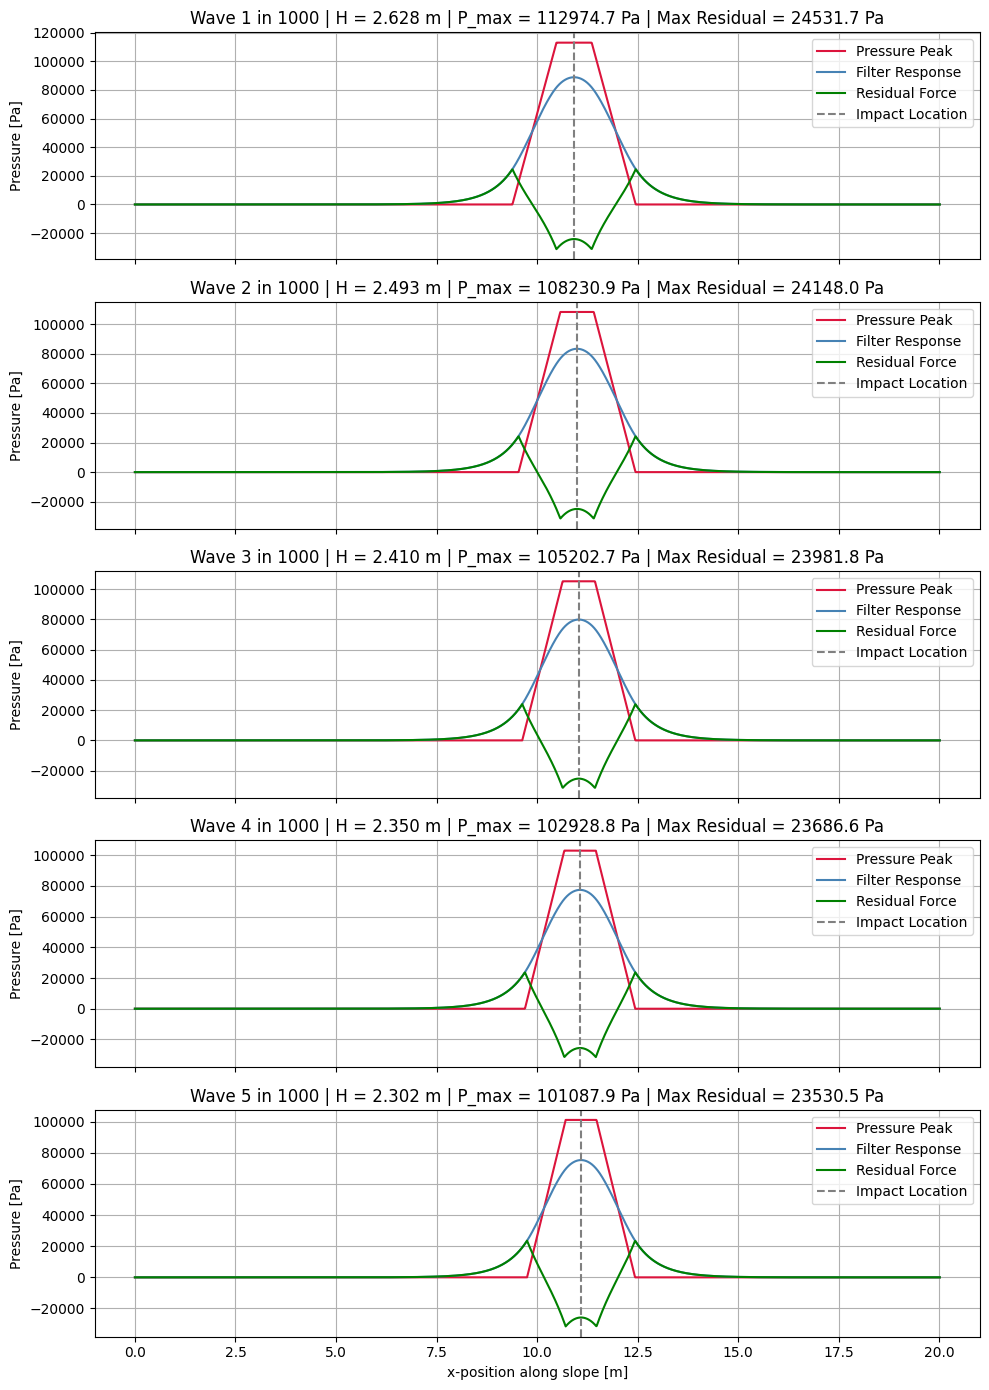

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
from scipy.interpolate import interp1d

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# --- Block locations (for info only) ---
block_x_centers = np.linspace(2.0, 12.5, 22)

# --- Generate wave heights (Rayleigh for Hs=1.0) ---
Hs = 1.0
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Storage for plots ---
fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else 0  # fallback
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2 if xi != 0.2 else 1e-6  # prevent divide by zero
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure using logical masks
    p_vals = np.zeros_like(x)
    ramp_up_mask = (x >= x_left_base) & (x < x_left_top)
    flat_top_mask = (x >= x_left_top) & (x <= x_right_top)
    ramp_down_mask = (x > x_right_top) & (x <= x_right_base)

    p_vals[ramp_up_mask] = P_max * (x[ramp_up_mask] - x_left_base) / (x_left_top - x_left_base)
    p_vals[flat_top_mask] = P_max
    p_vals[ramp_down_mask] = P_max * (x_right_base - x[ramp_down_mask]) / (x_right_base - x_right_top)
    np.set_printoptions(threshold=np.inf)
    
    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals
    df1 = residual

    # Plot
    axs[i].plot(x, p_vals, label="Pressure Peak", color="crimson")
    axs[i].plot(x, phi_F, label="Filter Response", color="steelblue")
    axs[i].plot(x, residual, label="Residual Force", color="green")
    axs[i].axvline(x=x_center, color='gray', linestyle='--', label='Impact Location')

    axs[i].set_ylabel("Pressure [Pa]")
    axs[i].legend(loc="upper right")
    axs[i].grid(True)
    axs[i].set_title(f"Wave {i+1} in 1000 | H = {H_wave:.3f} m | P_max = {np.max(p_vals):.1f} Pa | Max Residual = {np.max(residual):.1f} Pa")

axs[-1].set_xlabel("x-position along slope [m]")
plt.tight_layout()
plt.show()


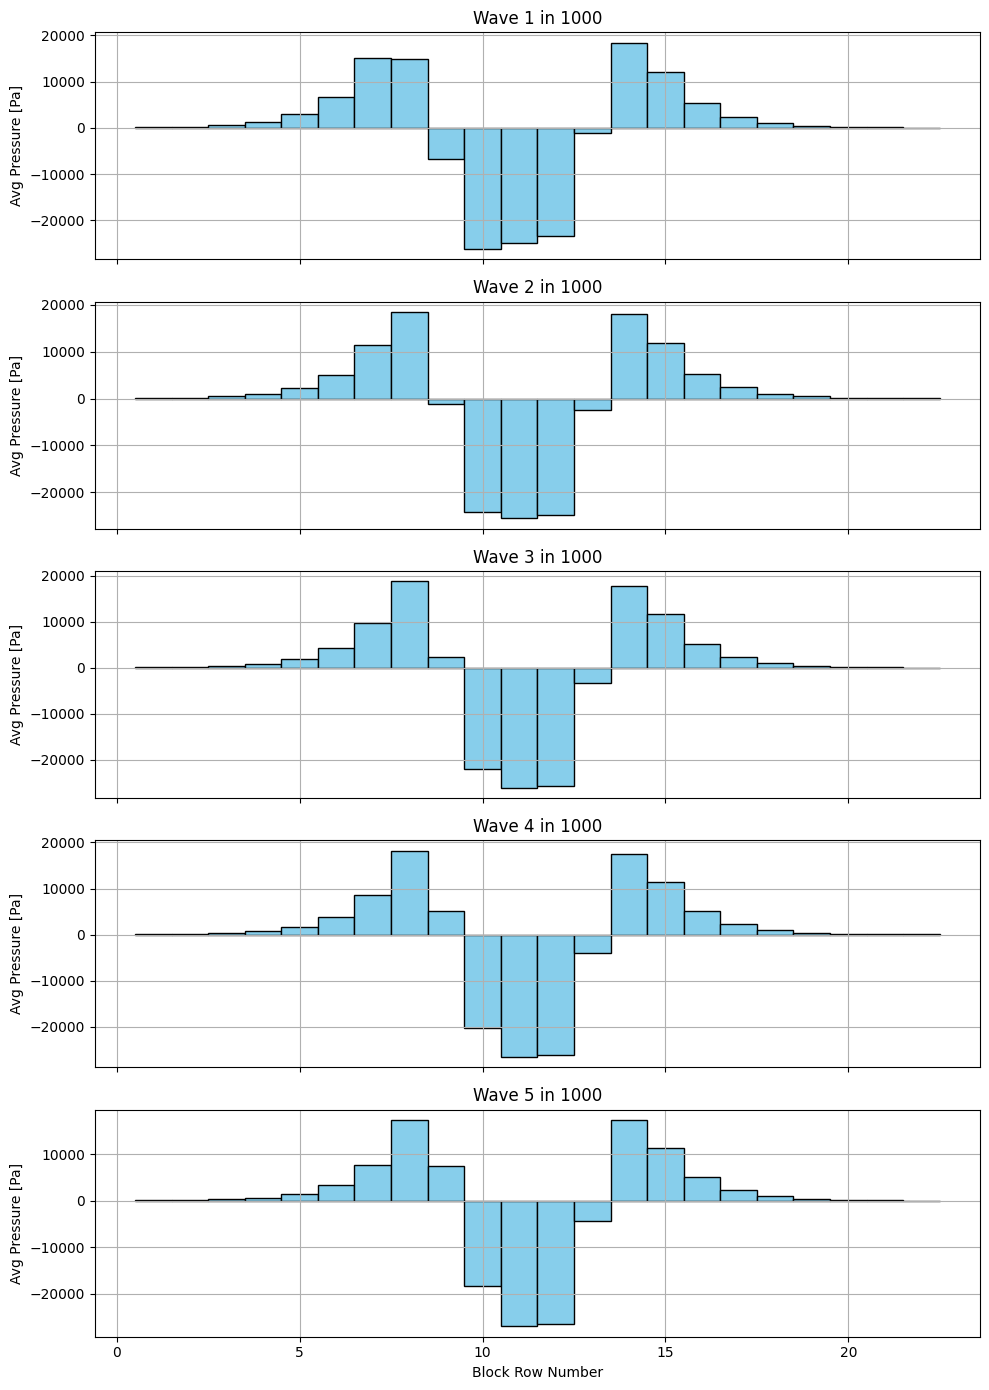

{'Wave 1 in 1000': [np.float64(115.93695973265189), np.float64(260.89674369193887), np.float64(588.450332794297), np.float64(1324.2090868989983), np.float64(2986.742060414537), np.float64(6721.163632924521), np.float64(15159.526026459658), np.float64(14960.367415053735), np.float64(-6751.740404146206), np.float64(-26243.439372681907), np.float64(-24930.76303421321), np.float64(-23375.30364626691), np.float64(-1135.7295327034944), np.float64(18440.70625662556), np.float64(12177.62677376004), np.float64(5451.698141312712), np.float64(2422.6186148886104), np.float64(1074.097967125851), np.float64(477.30626829006957), np.float64(211.6196315907277), np.float64(94.03922737378285), np.float64(41.69338279169406)], 'Wave 2 in 1000': [np.float64(87.98675624757605), np.float64(197.99948390870114), np.float64(446.5861112346811), np.float64(1004.9673755330796), np.float64(2266.6951613193382), np.float64(5100.8184761261355), np.float64(11504.851640017916), np.float64(18449.694249286218), np.float64(

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# --- Block parameters ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# --- Generate wave heights (Rayleigh for Hs=1.0) ---
Hs = 1.0
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Initialize storage ---
block_pressures_per_wave = {}

# Loop through each wave
for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    # Compute block pressures
    block_avg_pressures = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        avg_pressure = np.mean(residual[mask])
        block_avg_pressures.append(avg_pressure)

    block_pressures_per_wave[f"Wave {i+1} in 1000"] = block_avg_pressures

# Plot histogram of block pressures for each wave
fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for i, (wave_name, pressures) in enumerate(block_pressures_per_wave.items()):
    axs[i].bar(np.arange(1, 23), pressures, color='skyblue', width=1, edgecolor='black')
    axs[i].set_ylabel("Avg Pressure [Pa]")
    axs[i].set_title(f"{wave_name}")
    axs[i].grid(True)

axs[-1].set_xlabel("Block Row Number")
plt.tight_layout()
plt.show()

print(block_pressures_per_wave)


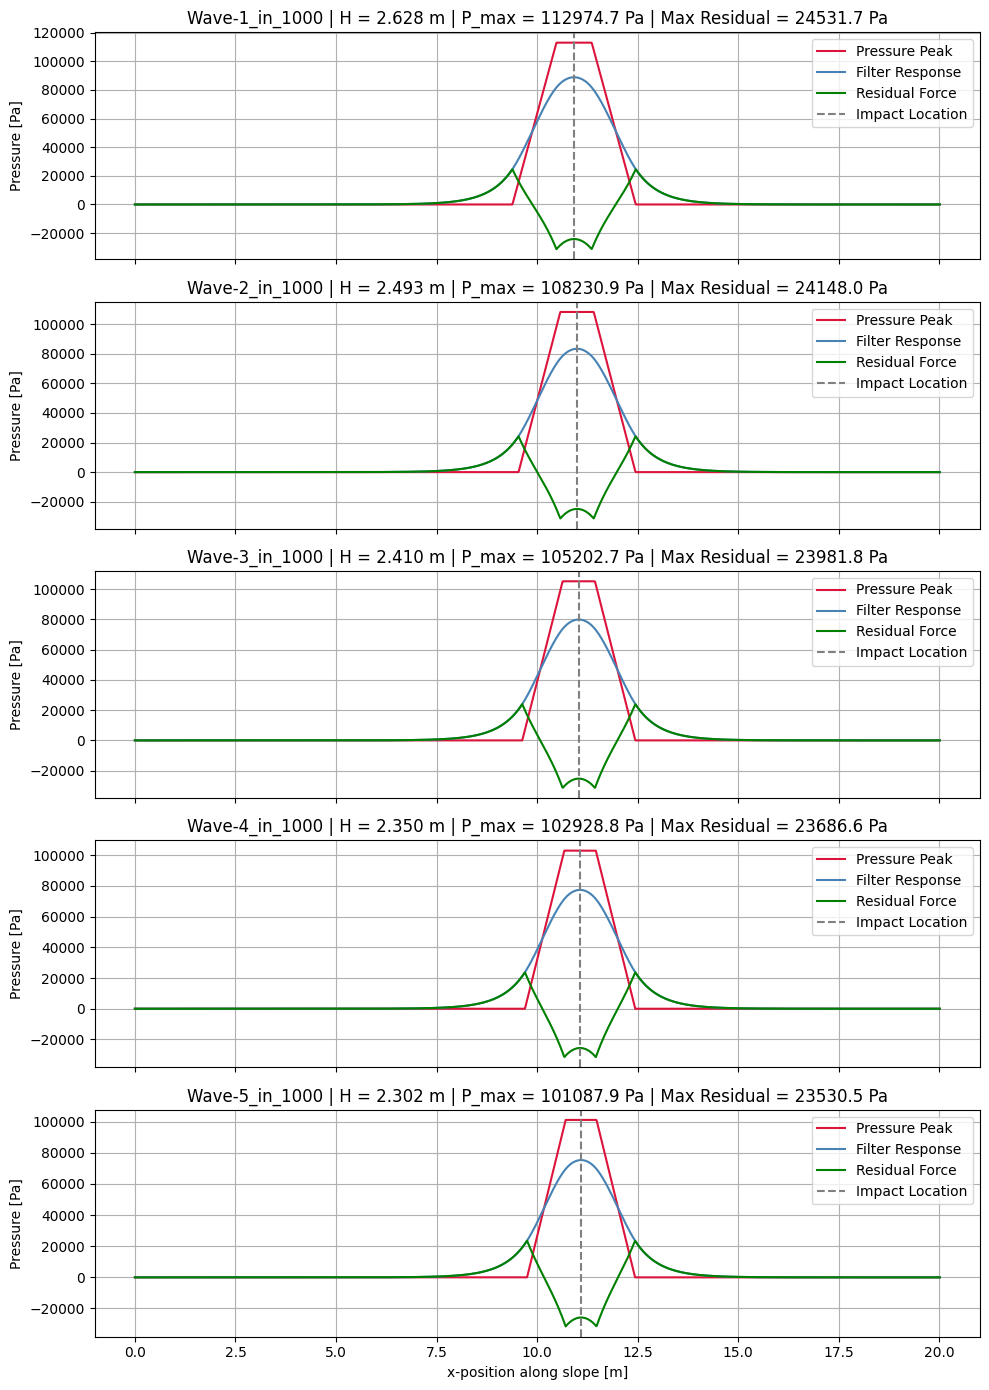

ModuleNotFoundError: No module named 'ace_tools'

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# --- Generate wave heights (Rayleigh for Hs=1.0) ---
Hs = 1.0
sigma = Hs / np.sqrt(2)
exceed_probs = np.arange(1, 6, 1) / 1000.0
wave_heights = sigma * np.sqrt(-2 * np.log(exceed_probs))

# --- Store all dataframes ---
dfs = {}

# --- Storage for plots ---
fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for i, H_wave in enumerate(wave_heights):
    wave_name = f"Wave-{i+1}_in_1000"
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else 0
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    denom = (xi - 0.2)**2 if xi != 0.2 else 1e-6
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    p_vals = np.zeros_like(x)
    ramp_up_mask = (x >= x_left_base) & (x < x_left_top)
    flat_top_mask = (x >= x_left_top) & (x <= x_right_top)
    ramp_down_mask = (x > x_right_top) & (x <= x_right_base)
    p_vals[ramp_up_mask] = P_max * (x[ramp_up_mask] - x_left_base) / (x_left_top - x_left_base)
    p_vals[flat_top_mask] = P_max
    p_vals[ramp_down_mask] = P_max * (x_right_base - x[ramp_down_mask]) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    # Store in DataFrame-like structure
    dfs[wave_name] = {
        "x": x,
        "p_vals": p_vals,
        "phi_F": phi_F,
        "residual": residual,
        "x_center": x_center,
        "H_wave": H_wave,
        "P_max": np.max(p_vals),
        "Max_Residual": np.max(residual)
    }

    # Plot
    axs[i].plot(x, p_vals, label="Pressure Peak", color="crimson")
    axs[i].plot(x, phi_F, label="Filter Response", color="steelblue")
    axs[i].plot(x, residual, label="Residual Force", color="green")
    axs[i].axvline(x=x_center, color='gray', linestyle='--', label='Impact Location')
    axs[i].set_ylabel("Pressure [Pa]")
    axs[i].legend(loc="upper right")
    axs[i].grid(True)
    axs[i].set_title(
        f"{wave_name} | H = {H_wave:.3f} m | P_max = {np.max(p_vals):.1f} Pa | Max Residual = {np.max(residual):.1f} Pa"
    )

axs[-1].set_xlabel("x-position along slope [m]")
plt.tight_layout()
plt.show()

import pandas as pd
dfs = {k: pd.DataFrame(v) for k, v in dfs.items()}
import ace_tools as tools; tools.display_dataframe_to_user(name="Wave Pressure and Response Data", dataframe=dfs["Wave-1_in_1000"])


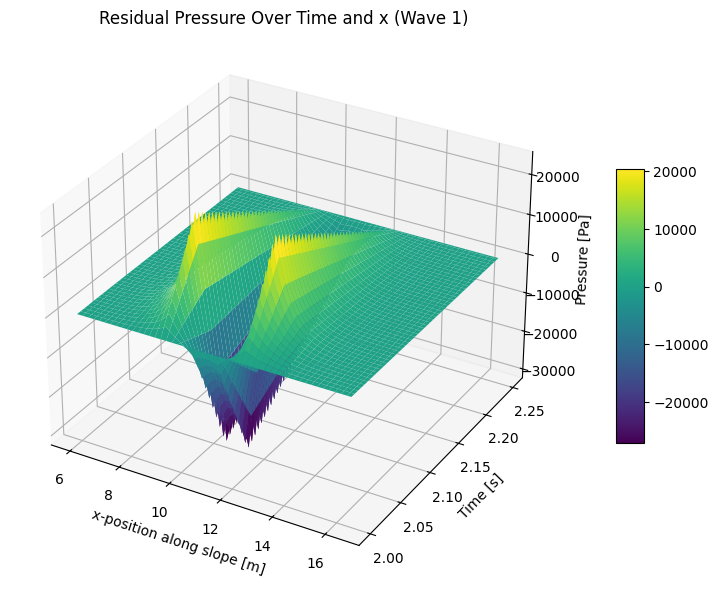

In [ ]:
# Fix: remove .values since it's already a NumPy array
residuals = dfs["Wave-1_in_1000"]["residual"]

# Interpolate over full x range
residual_interp = interp1d(x, residuals, bounds_error=False, fill_value=0)

# Fine x and time steps
x_fine = np.arange(6.0, 16.501, 0.01)
residual_fine = residual_interp(x_fine)

# Define time vector during forcing period
tt = np.linspace(2.0, 2.25, 126)  # dt = 0.01
pulse_shape = np.interp(tt - 2.0, [0, 0.05, 0.25], [0, 1, 0])
residual_func = interp1d(tt, pulse_shape, kind='linear', fill_value=0, bounds_error=False)

# Compute pressure matrix
T, X = np.meshgrid(tt, x_fine, indexing='ij')
Z = np.outer(pulse_shape, residual_fine)

# Plot 3D surface
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, T, Z, cmap='viridis')

ax.set_xlabel('x-position along slope [m]')
ax.set_ylabel('Time [s]')
ax.set_zlabel('Pressure [Pa]')
ax.set_title('Residual Pressure Over Time and x (Wave 1)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Time signal setup ---
total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
dt = 0.01
time = np.arange(0, pulse_interval * total_waves, dt)

# Pulse shape (triangle from 0 to 0.25s)
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

# --- Construct time-dependent pressure table ---
n_blocks = 22
data = np.zeros((len(time), n_blocks))

for wave_index, (wave_name, pressures) in enumerate(block_pressures_per_wave.items()):
    t_start = wave_index * pulse_interval
    t_end = t_start + pulse_duration
    active_indices = (time >= t_start) & (time <= t_end)
    local_time = time[active_indices] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)

    for i in range(n_blocks):
        data[active_indices, i] += pressures[i] * pulse

# --- Create DataFrame ---
columns = [f"ROW{i+1}" for i in range(n_blocks)]
df = pd.DataFrame(data, columns=columns)
df.insert(0, "TIME", time)
print(df_pulses)


     TIME       ROW1        ROW2        ROW3         ROW4         ROW5  \
0    0.00   0.000000    0.000000    0.000000     0.000000     0.000000   
1    0.01  23.187392   52.179349  117.690067   264.841817   597.348412   
2    0.02  46.374784  104.358697  235.380133   529.683635  1194.696824   
3    0.03  69.562176  156.538046  353.070200   794.525452  1792.045236   
4    0.04  92.749568  208.717395  470.760266  1059.367270  2389.393648   
..    ...        ...         ...         ...          ...          ...   
995  9.95   0.000000    0.000000    0.000000     0.000000     0.000000   
996  9.96   0.000000    0.000000    0.000000     0.000000     0.000000   
997  9.97   0.000000    0.000000    0.000000     0.000000     0.000000   
998  9.98   0.000000    0.000000    0.000000     0.000000     0.000000   
999  9.99   0.000000    0.000000    0.000000     0.000000     0.000000   

            ROW6          ROW7          ROW8         ROW9  ...       ROW13  \
0       0.000000      0.000000   

In [58]:
#----------------------------------------------------------------------------------------------------------------------------
script_dir = os.path.dirname(os.path.abspath(__file__))
# Construct full path to the input file relative to the script location
inp_path = os.path.join(script_dir, f"Job-1.inp")

# Output will go to the working directory (current directory)
output_path = os.path.join(script_dir, f"{job_name}.inp")

with open(inp_path, "r") as f:
    lines = f.readlines()

# 1. Read the original .inp file
# with open("Job-1.inp", "r") as f:
#     lines = f.readlines()

# 2. Replace job name line
for i, line in enumerate(lines):
    if line.strip().lower().startswith("** job name:"):
        lines[i] = f"** Job name: {job_name} Model name: Model-1\n"
        break

# 3. Find indices to insert amplitudes
start_index = None
materials_index = None

for i, line in enumerate(lines):
    if line.strip().lower() == "*end assembly":
        start_index = i
    elif line.strip().lower() == "** materials" and start_index is not None:
        materials_index = i
        break

if start_index is None or materials_index is None:
    raise RuntimeError("❌ Could not find '*End Assembly' and '** Materials' markers.")

# 4. Keep the line before '** Materials'
line_before_materials = lines[materials_index - 1]

# 5. Validate the TIME column
if not (df["TIME"].is_monotonic_increasing and df["TIME"].is_unique):
    raise ValueError("❌ TIME column must be strictly increasing and unique.")

# 6. Generate amplitude lines
amplitude_lines = []

for col in df.columns[1:]:  # Skip TIME
    amplitude_lines.append(f"*AMPLITUDE, NAME={col}\n")
    for i in range(0, len(df), 4):
        chunk = df.iloc[i:i+4]
        row_entries = []
        for t, val in zip(chunk["TIME"], chunk[col]):
            row_entries.append(f"{t:.3f}, {val:.5f}")
        amplitude_lines.append(", ".join(row_entries) + "\n")

# 7. Insert amplitudes into file structure
new_lines = lines[:start_index + 1] + amplitude_lines + [line_before_materials] + lines[materials_index:]

# 8. Export modified file

with open(output_path, "w") as f:
    f.writelines(new_lines)


print(f"✅ Read from: {inp_path}")
print(f"✅ Written to: {output_path}")
print(f"✅ Amplitudes inserted and job name updated in '{job_name}.inp'")

NameError: name 'os' is not defined

P_max = 61.17 kPa


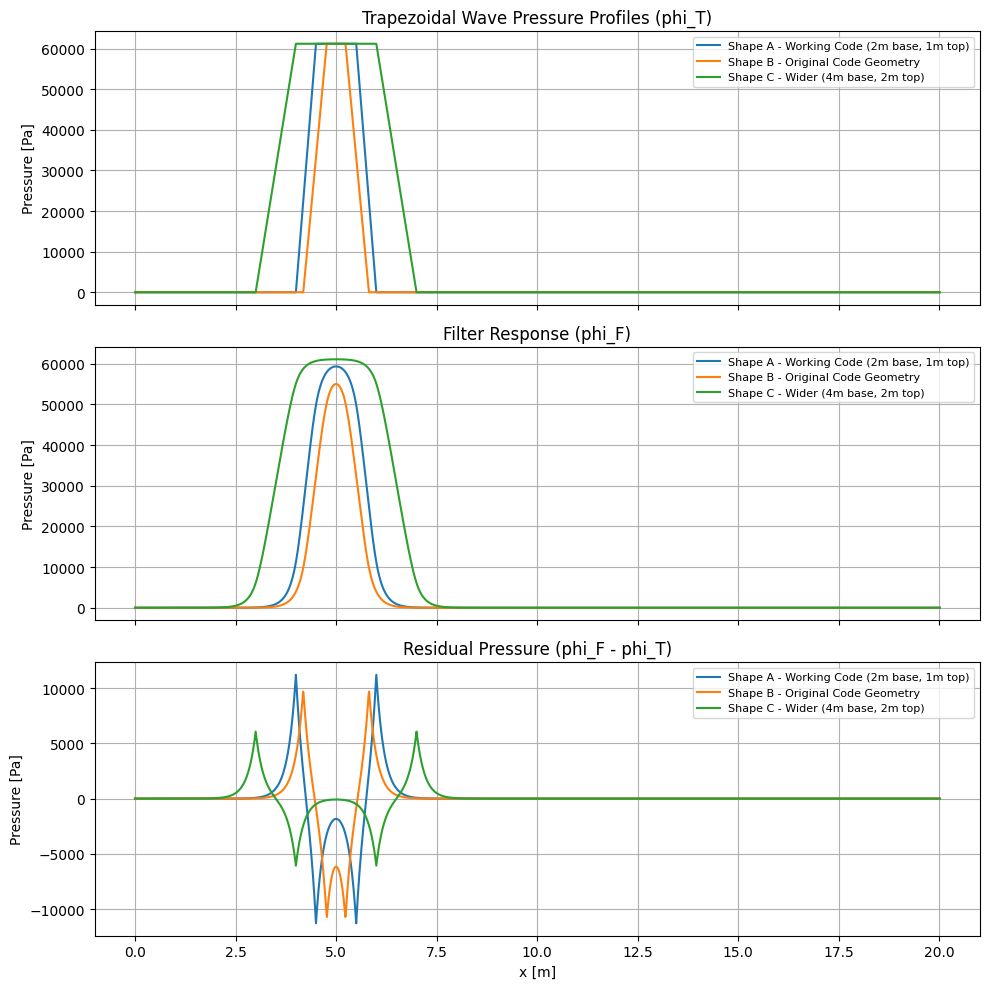

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# --- Physical parameters ---
rho_w = 1025.0       # [kg/m^3]
g = 9.81             # [m/s^2]
Hs = 1.4             # [m]
Tp = 5.59            # [s]
tan_beta = 1.0 / 3.0 # [-]

# --- Filter properties ---
D = 0.15
b = 0.07
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)

# Compute wave parameters
Tm_1_0 = Tp / 1.1
L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
xi = tan_beta / np.sqrt(Hs / L_m_1_0)

# Compute P_max
denom = (xi - 0.2)**2
P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
P_max = P_dimless * rho_w * g * Hs

print(f"P_max = {P_max/1000:.2f} kPa")

# Discretization
dx = 0.01
L = 20.0
x = np.arange(0, L + dx, dx)
N = len(x)

# --- Define trapezoid shapes ---

def trapezoid(x, center, w_base, w_top, P_max):
    x_left_base = center - w_base / 2
    x_right_base = center + w_base / 2
    x_left_top = center - w_top / 2
    x_right_top = center + w_top / 2

    p_vals = np.zeros_like(x)

    for i, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[i] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[i] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[i] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)
    return p_vals

# --- Shape definitions ---

shapes = {
    "Shape A - Working Code (2m base, 1m top)": {
        "center": 5.0,
        "w_base": 2.0,
        "w_top": 1.0
    },
    "Shape B - Original Code Geometry": {
        "center": 5.0,    # center it for comparison
        "w_base": (7/6) * Hs,
        "w_top": (1/3) * Hs
    },
    "Shape C - Wider (4m base, 2m top)": {
        "center": 5.0,
        "w_base": 4.0,
        "w_top": 2.0
    }
}

# --- Solve filter response for each shape ---
results = {}

for shape_name, params in shapes.items():
    p_vals = trapezoid(
        x,
        params["center"],
        params["w_base"],
        params["w_top"],
        P_max
    )

    # Setup matrix system
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0

    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0

    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    results[shape_name] = {
        "p_vals": p_vals,
        "phi_F": phi_F,
        "residual": residual
    }

# --- Plot comparison ---

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for shape_name, data in results.items():
    axs[0].plot(x, data["p_vals"], label=shape_name)
    axs[1].plot(x, data["phi_F"], label=shape_name)
    axs[2].plot(x, data["residual"], label=shape_name)

axs[0].set_title("Trapezoidal Wave Pressure Profiles (phi_T)")
axs[1].set_title("Filter Response (phi_F)")
axs[2].set_title("Residual Pressure (phi_F - phi_T)")

for ax in axs:
    ax.set_ylabel("Pressure [Pa]")
    ax.legend(fontsize=8)
    ax.grid(True)

axs[-1].set_xlabel("x [m]")

plt.tight_layout()
plt.show()


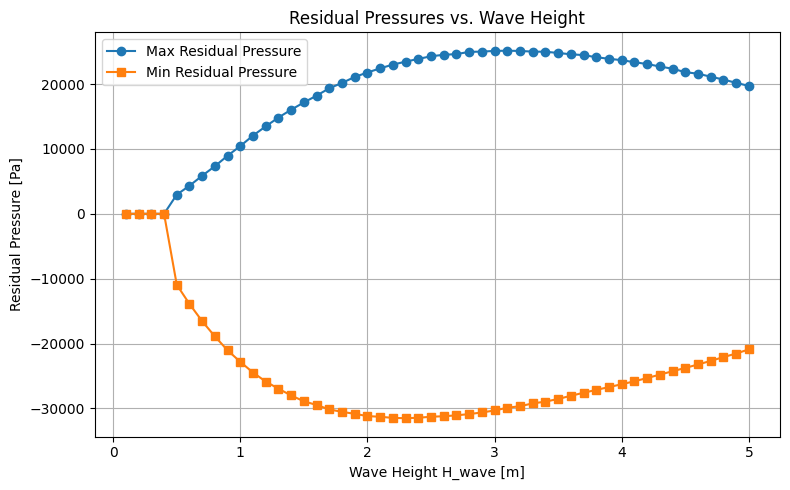

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# --- Define wave heights ---
wave_heights = np.arange(0.1, 5 + 0.1, 0.1)   # [1.0, 1.1, ..., 1.5]

# --- Storage for results ---
max_residuals = []
min_residuals = []

for H_wave in wave_heights:
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2 if abs(xi - 0.2) > 1e-6 else 1e-6
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    # Store max/min residual
    max_residuals.append(np.max(residual))
    min_residuals.append(np.min(residual))

# --- Plot results ---
plt.figure(figsize=(8,5))
plt.plot(wave_heights, max_residuals, marker='o', label='Max Residual Pressure')
plt.plot(wave_heights, min_residuals, marker='s', label='Min Residual Pressure')
plt.xlabel('Wave Height H_wave [m]')
plt.ylabel('Residual Pressure [Pa]')
plt.title('Residual Pressures vs. Wave Height')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Plotting residual curve for H_wave = 8.10 m


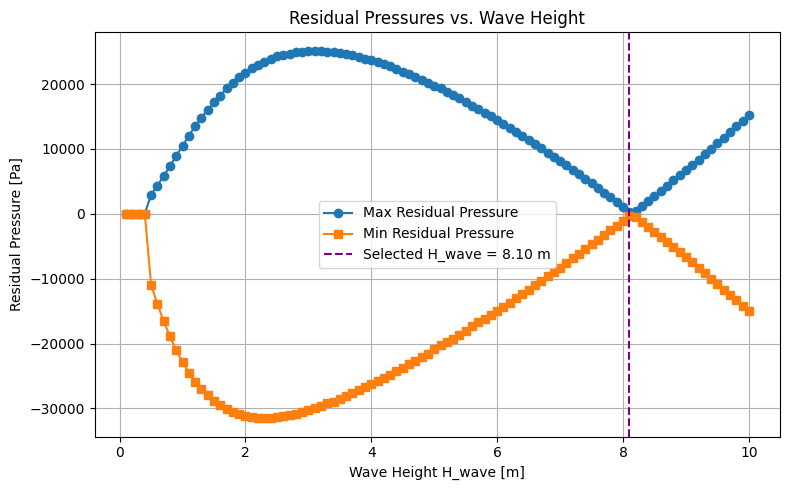

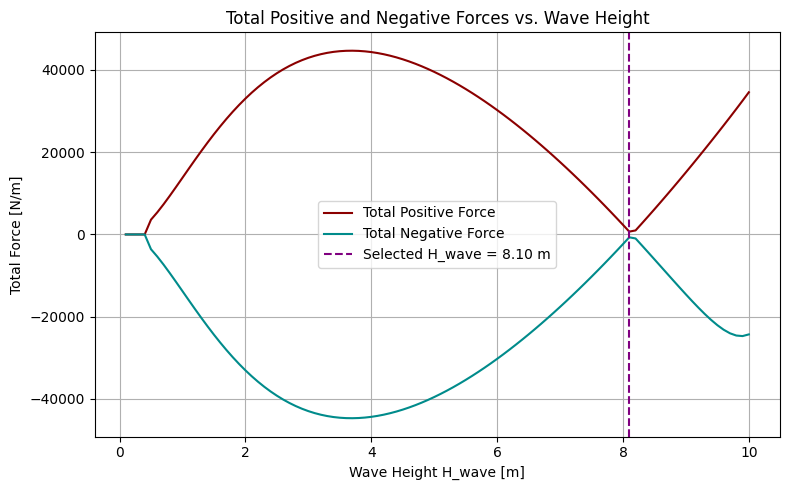

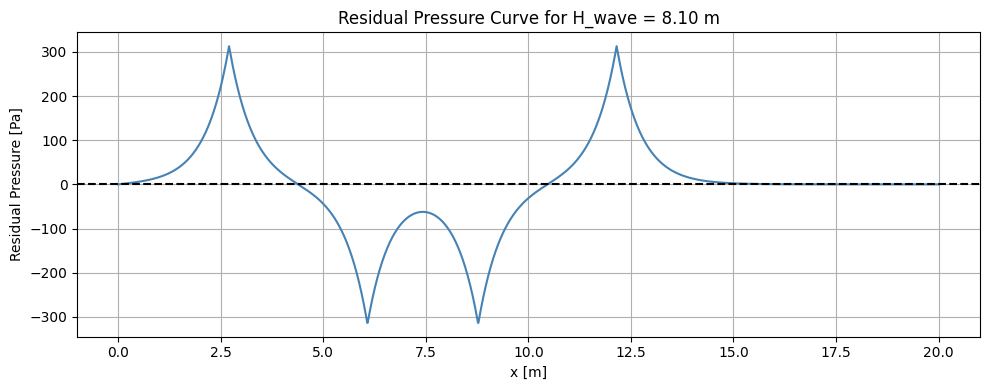

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# --- Define wave heights ---
wave_heights = np.arange(0.1, 10 + 0.1, 0.1)

# --- Choose wave height to inspect ---
H_wave_selected = 8.1

# --- Storage for results ---
max_residuals = []
min_residuals = []
total_positive_forces = []
total_negative_forces = []
residual_curves = {}

for H_wave in wave_heights:
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2 if abs(xi - 0.2) > 1e-6 else 1e-6
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    # Compute max/min residuals
    max_residuals.append(np.max(residual))
    min_residuals.append(np.min(residual))

    # Compute total positive and negative forces
    pos_force = np.sum(residual[residual > 0]) * dx
    neg_force = np.sum(residual[residual < 0]) * dx

    total_positive_forces.append(pos_force)
    total_negative_forces.append(neg_force)

    # Store residual curve
    residual_curves[H_wave] = residual

# --- Find closest wave height ---
H_wave_closest = min(wave_heights, key=lambda h: abs(h - H_wave_selected))
residual_selected = residual_curves[H_wave_closest]

print(f"Plotting residual curve for H_wave = {H_wave_closest:.2f} m")

# --- Plot max/min residuals ---
plt.figure(figsize=(8,5))
plt.plot(wave_heights, max_residuals, marker='o', label='Max Residual Pressure')
plt.plot(wave_heights, min_residuals, marker='s', label='Min Residual Pressure')
plt.axvline(H_wave_closest, color='purple', linestyle='--', label=f'Selected H_wave = {H_wave_closest:.2f} m')
plt.xlabel('Wave Height H_wave [m]')
plt.ylabel('Residual Pressure [Pa]')
plt.title('Residual Pressures vs. Wave Height')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot total positive & negative forces ---
plt.figure(figsize=(8,5))
plt.plot(wave_heights, total_positive_forces, marker='', color='darkred', label='Total Positive Force')
plt.plot(wave_heights, total_negative_forces, marker='', color='darkcyan', label='Total Negative Force')
plt.axvline(H_wave_closest, color='purple', linestyle='--', label=f'Selected H_wave = {H_wave_closest:.2f} m')
plt.xlabel('Wave Height H_wave [m]')
plt.ylabel('Total Force [N/m]')
plt.title('Total Positive and Negative Forces vs. Wave Height')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot residual curve for selected wave height ---
plt.figure(figsize=(10,4))
plt.plot(x, residual_selected, color='steelblue')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('x [m]')
plt.ylabel('Residual Pressure [Pa]')
plt.title(f'Residual Pressure Curve for H_wave = {H_wave_closest:.2f} m')
plt.grid(True)
plt.tight_layout()
plt.show()


Plotting residual curve for H_wave = 2.30 m


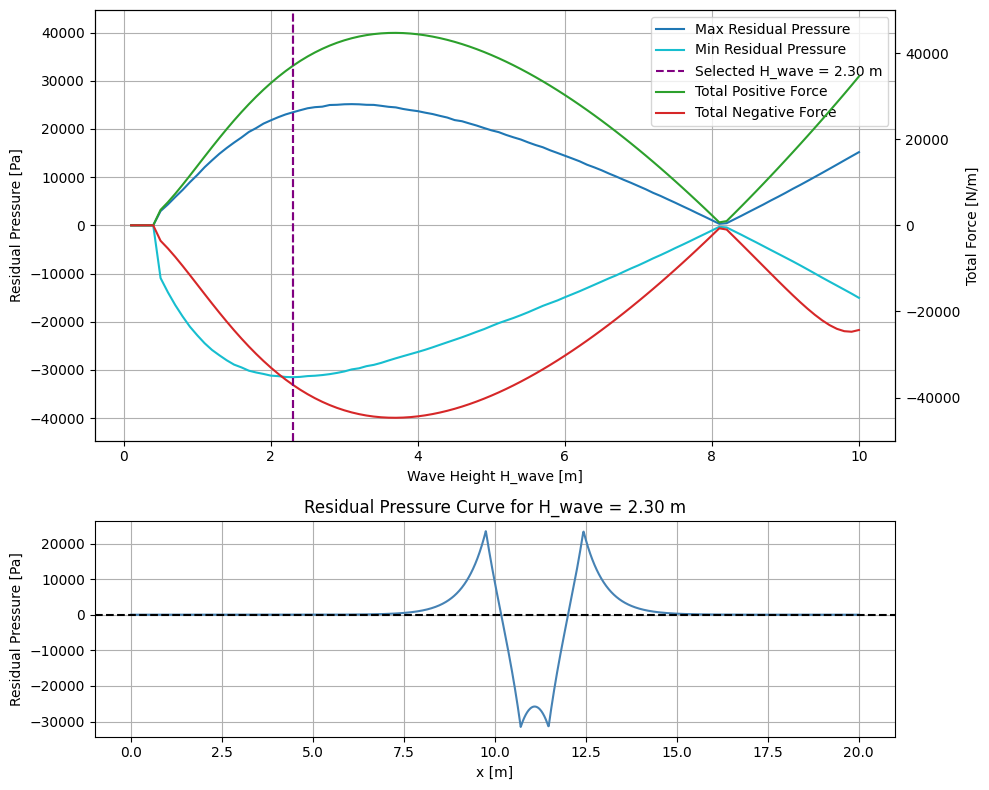

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.30
b = 0.30
k = 0.19
k_prime = 0.05
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)

# --- Define wave heights ---
wave_heights = np.arange(0.1, 10.0 + 0.1, 0.1)

# --- Choose wave height to inspect ---
H_wave_selected = 2.3

# --- Storage for results ---
max_residuals = []
min_residuals = []
total_positive_forces = []
total_negative_forces = []
residual_curves = {}

for H_wave in wave_heights:
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2 if abs(xi - 0.2) > 1e-6 else 1e-6
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    # Compute max/min residuals
    max_residuals.append(np.max(residual))
    min_residuals.append(np.min(residual))

    # Compute total positive and negative forces
    pos_force = np.sum(residual[residual > 0]) * dx
    neg_force = np.sum(residual[residual < 0]) * dx

    total_positive_forces.append(pos_force)
    total_negative_forces.append(neg_force)

    # Store residual curve
    residual_curves[H_wave] = residual

# --- Find closest wave height ---
H_wave_closest = min(wave_heights, key=lambda h: abs(h - H_wave_selected))
residual_selected = residual_curves[H_wave_closest]

print(f"Plotting residual curve for H_wave = {H_wave_closest:.2f} m")

# --- Compute unified scale for aligned zero ---
# Find max absolute values for both data series
resid_abs_max = max(np.max(max_residuals), abs(np.min(min_residuals)))
force_abs_max = max(np.max(total_positive_forces), abs(np.min(total_negative_forces)))

# Choose a common limit for both axes
common_limit = max(resid_abs_max, force_abs_max)

# --- Create figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=False)

# --- Top plot: residual pressures + forces ---
color_max = 'tab:blue'
color_min = 'tab:cyan'
color_pos = 'tab:green'
color_neg = 'tab:red'

# Plot max/min residual pressure
ax1.set_xlabel('Wave Height H_wave [m]')
ax1.set_ylabel('Residual Pressure [Pa]', color='black')
ax1.plot(wave_heights, max_residuals, marker='', color=color_max, label='Max Residual Pressure')
ax1.plot(wave_heights, min_residuals, marker='', color=color_min, label='Min Residual Pressure')
ax1.tick_params(axis='y', labelcolor='black')

# Create second y-axis for forces
ax1b = ax1.twinx()
ax1b.set_ylabel('Total Force [N/m]', color='black')
ax1b.plot(wave_heights, total_positive_forces, marker='', color=color_pos, label='Total Positive Force')
ax1b.plot(wave_heights, total_negative_forces, marker='', color=color_neg, label='Total Negative Force')
ax1b.tick_params(axis='y', labelcolor='black')

# Force matching zero lines:
ax1.set_ylim(-common_limit, common_limit)
ax1b.set_ylim(-50000, 50000)

# Vertical line for selected wave height
ax1.axvline(H_wave_closest, color='purple', linestyle='--', label=f'Selected H_wave = {H_wave_closest:.2f} m')
ax1b.axvline(H_wave_closest, color='purple', linestyle='--')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

ax1.grid(True)

# --- Bottom plot: residual curve for selected wave height ---
ax2.plot(x, residual_selected, color='steelblue')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_xlabel('x [m]')
ax2.set_ylabel('Residual Pressure [Pa]')
ax2.set_title(f'Residual Pressure Curve for H_wave = {H_wave_closest:.2f} m')
ax2.grid(True)

plt.tight_layout()
plt.show()


0.5477225575051661


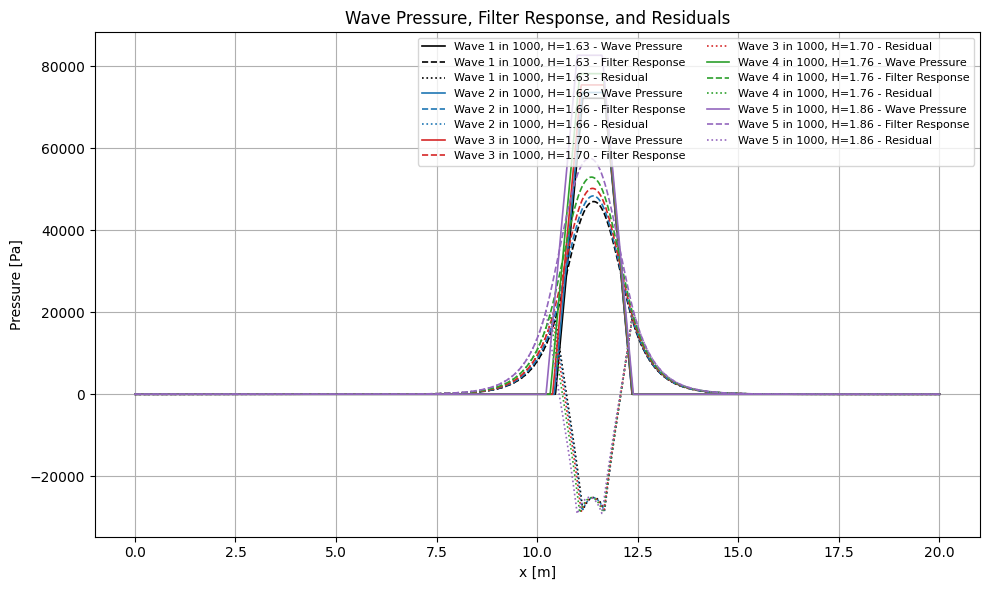

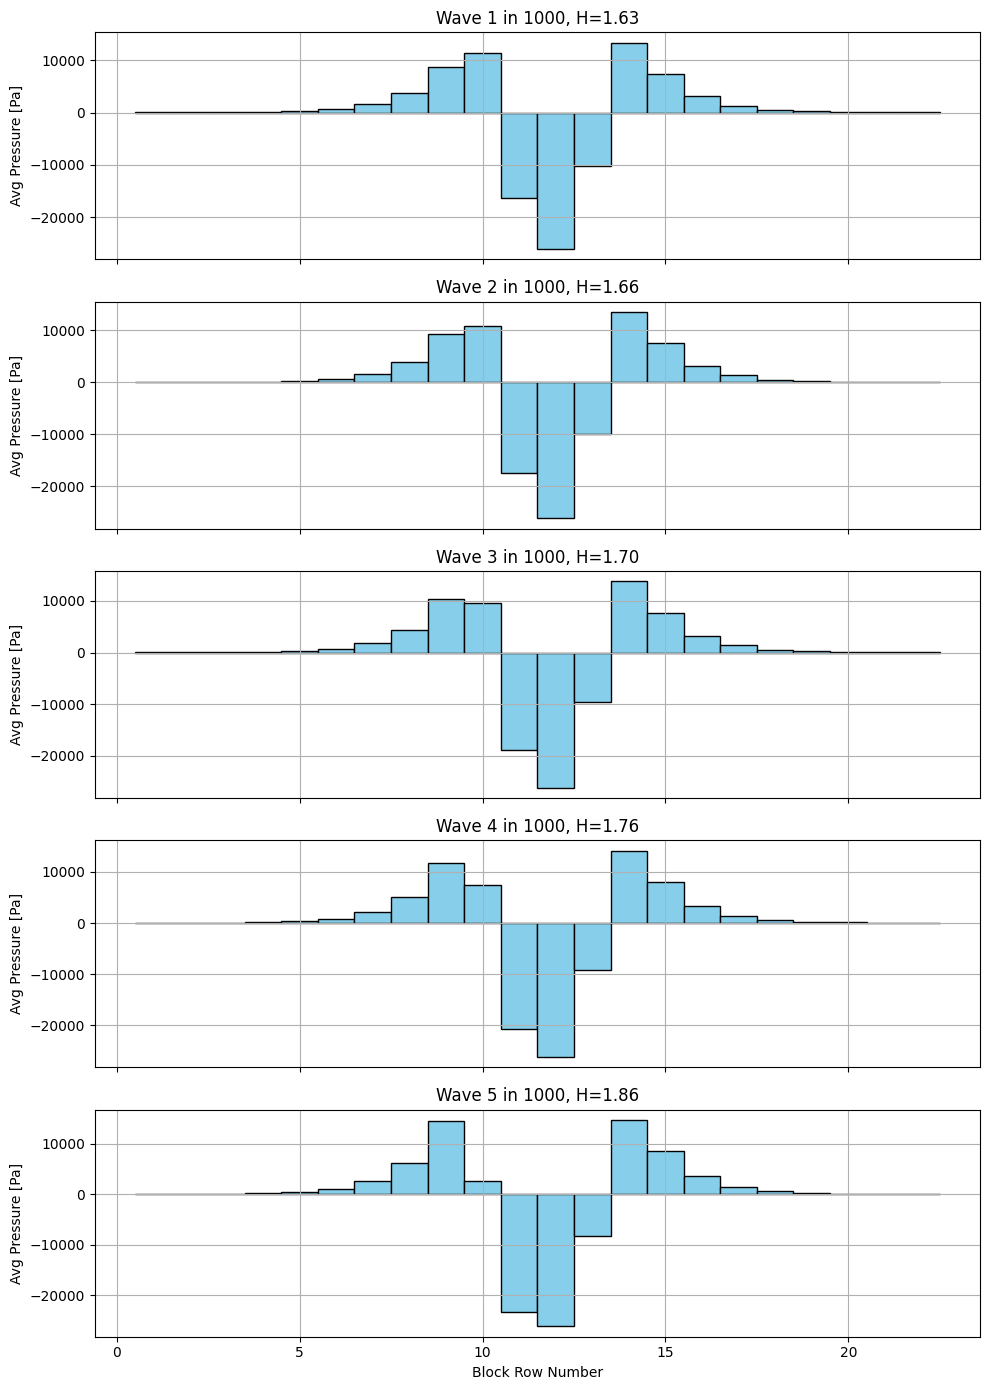

{'Wave 1 in 1000, H=1.63': [np.float64(8.580807763410048), np.float64(20.398068880581782), np.float64(48.61629344547659), np.float64(115.56936475672752), np.float64(275.4453954985192), np.float64(654.781496629923), np.float64(1560.5913269828043), np.float64(3709.7963567699344), np.float64(8750.08785236125), np.float64(11386.46424895538), np.float64(-16320.59695314546), np.float64(-26089.71264311591), np.float64(-10215.087448228294), np.float64(13337.581848319527), np.float64(7338.595905300384), np.float64(3111.362629956944), np.float64(1308.84961540448), np.float64(549.1575498327419), np.float64(231.01281673546427), np.float64(96.92666602951758), np.float64(40.773907742579546), np.float64(17.107605245009854)], 'Wave 2 in 1000, H=1.66': [np.float64(9.202165562080127), np.float64(21.875144177712308), np.float64(52.13672111472141), np.float64(123.9380321431649), np.float64(295.39108701378376), np.float64(702.1958660661832), np.float64(1673.5976567239857), np.float64(3978.4320098824596), n

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.linalg import solve
import pandas as pd
from scipy.interpolate import interp1d
import os

# JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME  JOBNAME 

Hs = 1.0
density_value = 2300.0
youngs_modulus_value = 30e9

# Format values into the job name
Hs_str = str(Hs).replace('.', '_')  # "0.6" → "0_6"
E_str = int(youngs_modulus_value / 1e9)  # 30e9 → 30

job_name = "Job-H-{}_{}_{:02d}".format(Hs_str, int(density_value), E_str)

# --- Constants ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.15
b = 0.1
k = 0.3
k_prime = 0.015
Lambda = np.sqrt(D * b * k / k_prime)
print(Lambda)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)
N = len(x)
H_wave_width = Hs

# --- Block parameters ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]

# --- Generate top 5 wave heights using alternative Rayleigh approach ---

n = 1000
p_values = [(k + 1) / float(n + 1) for k in range(5)]  # [1/1001, ..., 5/1001]
wave_heights = sorted([round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2) for p in p_values])

# --- Initialize storage ---
block_pressures_per_wave = {}
residual_profiles = {}  
wave_pressures = {}
filter_responses = {}

# Loop through each wave

for i, H_wave in enumerate(wave_heights):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)
    z_SWL = H_wave * (0.8 + 0.6 * np.tanh(xi - 2.1)) if xi < 3 else np.nan
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7 / 6) * H_wave
    w_top = (1 / 3) * H_wave
    x_left_base = x_center - w_base / 2
    x_right_base = x_center + w_base / 2
    x_left_top = x_center - w_top / 2
    x_right_top = x_center + w_top / 2

    # Calculate P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    # Build trapezoidal wave pressure
    p_vals = np.zeros_like(x)
    for j, xx in enumerate(x):
        if x_left_base <= xx < x_left_top:
            p_vals[j] = P_max * (xx - x_left_base) / (x_left_top - x_left_base)
        elif x_left_top <= xx <= x_right_top:
            p_vals[j] = P_max
        elif x_right_top < xx <= x_right_base:
            p_vals[j] = P_max * (x_right_base - xx) / (x_right_base - x_right_top)

    # Solve for filter response
    b_vec = -p_vals.copy()
    b_vec[0] = b_vec[-1] = 0
    A = np.zeros((N, N))
    coeff = Lambda**2 / dx**2
    for j in range(1, N - 1):
        A[j, j - 1] = coeff
        A[j, j] = -2 * coeff - 1
        A[j, j + 1] = coeff
    A[0, 0] = A[-1, -1] = 1.0
    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals

    wave_name = f"Wave {i+1} in 1000, H={H_wave:.2f}"
    wave_pressures[wave_name] = p_vals
    filter_responses[wave_name] = phi_F
    residual_profiles[wave_name] = residual

    # Compute block pressures
    block_avg_pressures = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        avg_pressure = np.mean(residual[mask])
        block_avg_pressures.append(avg_pressure)

    block_pressures_per_wave[f"Wave {i+1} in 1000, H={H_wave:.2f}"] = block_avg_pressures

# Plot histogram of block pressures for each wave
plt.figure(figsize=(10, 6))

colors = ["black", "tab:blue", "tab:red", "tab:green", "tab:purple"]
linestyles = ["-", "--", ":"]

for idx, wave_name in enumerate(wave_pressures.keys()):
    color = colors[idx % len(colors)]
    plt.plot(x, wave_pressures[wave_name],
             linestyle=linestyles[0],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Wave Pressure")

    plt.plot(x, filter_responses[wave_name],
             linestyle=linestyles[1],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Filter Response")

    plt.plot(x, residual_profiles[wave_name],
             linestyle=linestyles[2],
             color=color,
             linewidth=1.2,
             label=f"{wave_name} - Residual")

plt.xlabel("x [m]")
plt.ylabel("Pressure [Pa]")
plt.title("Wave Pressure, Filter Response, and Residuals")
plt.legend(ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot histogram of block pressures for each wave
fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

for i, (wave_name, pressures) in enumerate(block_pressures_per_wave.items()):
    axs[i].bar(np.arange(1, 23), pressures, color='skyblue', width=1, edgecolor='black')
    axs[i].set_ylabel("Avg Pressure [Pa]")
    axs[i].set_title(f"{wave_name}")
    axs[i].grid(True)

axs[-1].set_xlabel("Block Row Number")
plt.tight_layout()
plt.show()

print(block_pressures_per_wave)

# -----------------------------------------------------------------------------------------------------------------


# --- Time signal setup ---
total_waves = 5
pulse_duration = 0.25
pulse_interval = 2.0
dt = 0.01
time = np.arange(0, pulse_interval * total_waves, dt)

# Pulse shape (triangle from 0 to 0.25s)
pulse_t = np.array([0.0, 0.05, 0.25])
pulse_val = np.array([0.0, 1.0, 0.0])

# --- Construct time-dependent pressure table ---
n_blocks = 22
data = np.zeros((len(time), n_blocks))

for wave_index, (wave_name, pressures) in enumerate(block_pressures_per_wave.items()):
    t_start = wave_index * pulse_interval
    t_end = t_start + pulse_duration
    active_indices = (time >= t_start) & (time <= t_end)
    local_time = time[active_indices] - t_start
    pulse = np.interp(local_time, pulse_t, pulse_val)

    for i in range(n_blocks):
        data[active_indices, i] += pressures[i] * pulse

# --- Create DataFrame ---
columns = [f"ROW{i+1}" for i in range(n_blocks)]
df = pd.DataFrame(data, columns=columns)
df.insert(0, "TIME", time)
print(df)

#----------------------------------------------------------------------------------------------------------------------------




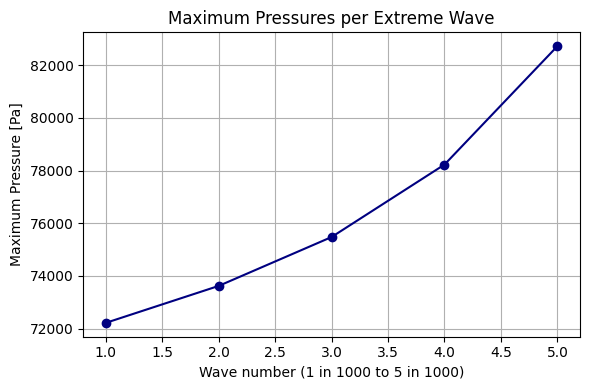

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve
import pandas as pd

Hs = 1.0
density_value = 2300.0
youngs_modulus_value = 30e9

rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.15
b = 0.1
k = 0.3
k_prime = 0.015
Lambda = np.sqrt(D * b * k / k_prime)
SWL = 4.7
dx = 0.01
x = np.arange(0, 20.0 + dx, dx)

# --- Generate top 5 wave heights ---
n = 1000
p_values = [(k + 1) / float(n + 1) for k in range(5)]
wave_heights = sorted([round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2) for p in p_values])

max_pressures = []

# Loop through each wave
for H_wave in wave_heights:
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H_wave / L_m_1_0)

    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H_wave

    max_pressures.append(P_max)

# --- Plot only the maximum pressures ---
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(max_pressures) + 1), max_pressures, 'o-', color='navy', markersize=6)
plt.xlabel("Wave number (1 in 1000 to 5 in 1000)")
plt.ylabel("Maximum Pressure [Pa]")
plt.title("Maximum Pressures per Extreme Wave")
plt.grid(True)
plt.tight_layout()
plt.show()


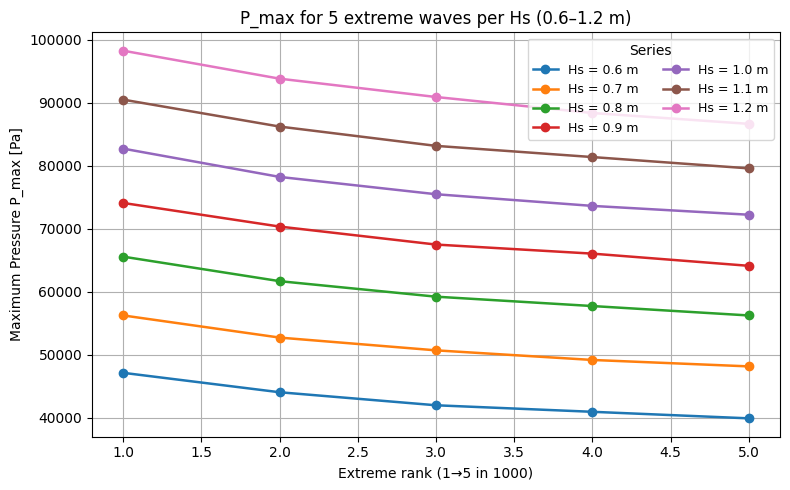

In [4]:
from __future__ import division, print_function
import numpy as np
import matplotlib.pyplot as plt

# --- Constants (same as your code where relevant) ---
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0

# Build Hs list: 0.6 to 1.2 with step 0.1 (Python 2.7-safe)
Hs_values = []
v = 0.6
while v <= 1.2000001:
    Hs_values.append(round(v, 1))
    v += 0.1

# Rayleigh "top 5 in 1000" probabilities (1/1001 .. 5/1001)
n = 1000
p_values = [ (k + 1.0) / (n + 1.0) for k in range(5) ]  # 5 ranks

def extreme_heights_for_Hs(Hs):
    # H_k = Hs * sqrt(0.5 * ln(1/p_k))
    return [ round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2) for p in p_values ]

def pmax_for_wave(H):
    # Compute xi using your formulation
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * Tm_1_0**2) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H / L_m_1_0)

    # Dimensionless pressure and P_max
    denom = (xi - 0.2)**2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    return P_dimless * rho_w * g * H

# Collect and plot
plt.figure(figsize=(8, 5))

rank_x = [1, 2, 3, 4, 5]  # 1-in-1000 ... 5-in-1000 ranks
for Hs in Hs_values:
    waves = extreme_heights_for_Hs(Hs)     # 5 extreme waves for this Hs
    pmax = [pmax_for_wave(H) for H in waves]  # P_max per wave
    plt.plot(rank_x, pmax, marker='o', linewidth=1.8, label="Hs = {:.1f} m".format(Hs))

plt.xlabel("Extreme rank (1→5 in 1000)")
plt.ylabel("Maximum Pressure P_max [Pa]")
plt.title("P_max for 5 extreme waves per Hs (0.6–1.2 m)")
plt.grid(True)
plt.legend(title="Series", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


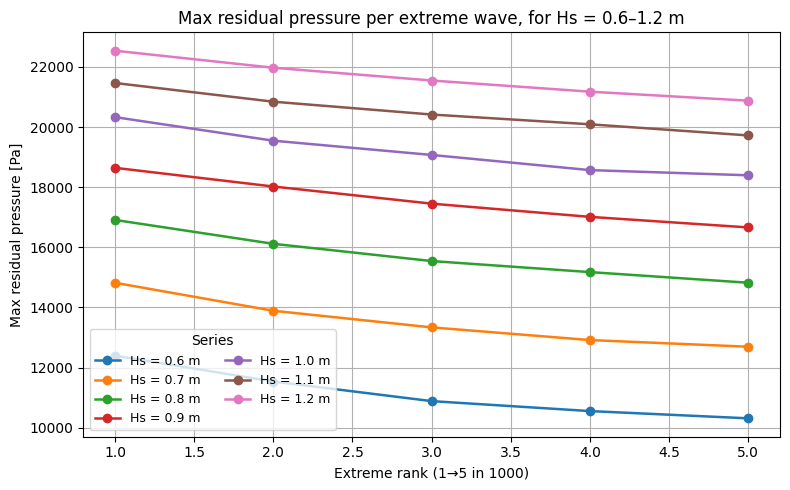

In [5]:
from __future__ import division, print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# ---------------- Constants (from your model) ----------------
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.15
b = 0.1
k = 0.3
k_prime = 0.015
Lambda = np.sqrt(D * b * k / k_prime)

SWL = 4.7
dx = 0.01
x = np.arange(0.0, 20.0 + dx, dx)
N = len(x)

# Block geometry (not strictly needed for max over x, but keeping structure)
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))

# ---------------- Helper: 5 extreme waves for a given Hs ----------------
n = 1000
p_values = [ (k + 1.0) / (n + 1.0) for k in range(5) ]  # 1/1001 .. 5/1001

def extreme_heights_for_Hs(Hs):
    # H_k = Hs * sqrt(0.5 * ln(1/p_k))
    vals = []
    for p in p_values:
        vals.append(round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2))
    return vals

# ---------------- Prebuild the linear system matrix A ----------------
A = np.zeros((N, N))
coeff = (Lambda ** 2) / (dx ** 2)
for j in range(1, N - 1):
    A[j, j - 1] = coeff
    A[j, j]     = -2.0 * coeff - 1.0
    A[j, j + 1] = coeff
A[0, 0]   = 1.0
A[-1, -1] = 1.0

# ---------------- P_max and residual helpers ----------------
def compute_xi(H):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * (Tm_1_0 ** 2)) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H / L_m_1_0)
    return xi

def trapezoid_pressure_over_x(H):
    """
    Build trapezoidal pressure p_vals(x) for a wave of height H.
    If xi >= 3, return zeros (as in your original code path where z_SWL becomes NaN).
    """
    xi = compute_xi(H)
    if xi >= 3.0:
        return np.zeros_like(x)

    z_SWL = H * (0.8 + 0.6 * np.tanh(xi - 2.1))  # xi < 3 guaranteed here
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7.0 / 6.0) * H
    w_top  = (1.0 / 3.0) * H

    x_left_base  = x_center - w_base / 2.0
    x_right_base = x_center + w_base / 2.0
    x_left_top   = x_center - w_top  / 2.0
    x_right_top  = x_center + w_top  / 2.0

    # Dimensionless max pressure and scale to Pa
    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H

    p_vals = np.zeros_like(x)

    # Rising edge
    mask_rise = (x >= x_left_base) & (x < x_left_top)
    if np.any(mask_rise) and (x_left_top != x_left_base):
        p_vals[mask_rise] = P_max * (x[mask_rise] - x_left_base) / (x_left_top - x_left_base)

    # Top
    mask_top = (x >= x_left_top) & (x <= x_right_top)
    p_vals[mask_top] = P_max

    # Falling edge
    mask_fall = (x > x_right_top) & (x <= x_right_base)
    if np.any(mask_fall) and (x_right_base != x_right_top):
        p_vals[mask_fall] = P_max * (x_right_base - x[mask_fall]) / (x_right_base - x_right_top)

    return p_vals

def max_residual_for_wave(H):
    """
    Solve for phi_F with the current wave's p(x), compute residual = phi_F - p,
    and return the maximum residual over x.
    """
    p_vals = trapezoid_pressure_over_x(H)

    b_vec = -p_vals.copy()
    b_vec[0]  = 0.0
    b_vec[-1] = 0.0

    phi_F = solve(A, b_vec)
    residual = phi_F - p_vals
    return float(np.max(residual))

# ---------------- Main sweep: Hs = 0.6 .. 1.2 (step 0.1) ----------------
Hs_values = []
v = 0.6
while v <= 1.2000001:
    Hs_values.append(round(v, 1))
    v += 0.1

rank_x = [1, 2, 3, 4, 5]  # "1 in 1000" to "5 in 1000"

plt.figure(figsize=(8, 5))

for Hs in Hs_values:
    waves = extreme_heights_for_Hs(Hs)             # five extreme H for this Hs
    max_residuals = [max_residual_for_wave(H) for H in waves]  # max over x per wave
    plt.plot(rank_x, max_residuals, marker='o', linewidth=1.8, label="Hs = {:.1f} m".format(Hs))

plt.xlabel("Extreme rank (1→5 in 1000)")
plt.ylabel("Max residual pressure [Pa]")
plt.title("Max residual pressure per extreme wave, for Hs = 0.6–1.2 m")
plt.grid(True)
plt.legend(title="Series", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


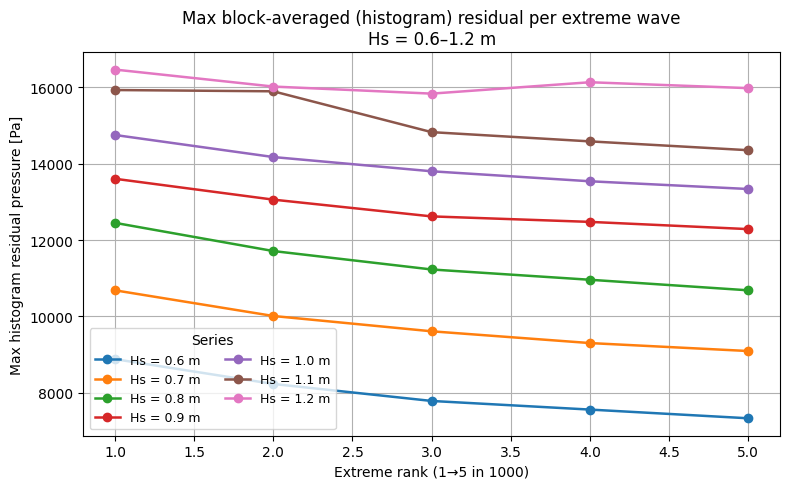

In [6]:
from __future__ import division, print_function
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# ---------------- Constants (from your model) ----------------
rho_w = 1025.0
g = 9.81
Tp = 5.59
tan_beta = 1.0 / 3.0
D = 0.15
b = 0.1
k = 0.3
k_prime = 0.015
Lambda = np.sqrt(D * b * k / k_prime)

SWL = 4.7
dx = 0.01
x = np.arange(0.0, 20.0 + dx, dx)
N = len(x)

# --- Block parameters (histogram bins) ---
block_length = 0.5
slope = tan_beta
block_dx = block_length * np.cos(np.arctan(slope))
block_start = 6.0
block_positions = [block_start + i * block_dx for i in range(22)]  # 22 blocks

# ---------------- Helper: 5 extreme waves for a given Hs ----------------
n = 1000
p_values = [ (k + 1.0) / (n + 1.0) for k in range(5) ]  # 1/1001 .. 5/1001

def extreme_heights_for_Hs(Hs):
    # H_k = Hs * sqrt(0.5 * ln(1/p_k))
    vals = []
    for p in p_values:
        vals.append(round(Hs * np.sqrt(0.5 * np.log(1.0 / p)), 2))
    return vals

# ---------------- Prebuild the linear system matrix A ----------------
A = np.zeros((N, N))
coeff = (Lambda ** 2) / (dx ** 2)
for j in range(1, N - 1):
    A[j, j - 1] = coeff
    A[j, j]     = -2.0 * coeff - 1.0
    A[j, j + 1] = coeff
A[0, 0]   = 1.0
A[-1, -1] = 1.0

# ---------------- Physics helpers ----------------
def compute_xi(H):
    Tm_1_0 = Tp / 1.1
    L_m_1_0 = (g * (Tm_1_0 ** 2)) / (2.0 * np.pi)
    xi = tan_beta / np.sqrt(H / L_m_1_0)
    return xi

def trapezoid_pressure_over_x(H):
    """
    Build trapezoidal pressure p_vals(x) for a wave of height H.
    Replicates your behavior: if xi >= 3, return zeros.
    """
    xi = compute_xi(H)
    if xi >= 3.0:
        return np.zeros_like(x)

    z_SWL = H * (0.8 + 0.6 * np.tanh(xi - 2.1))  # xi < 3 guaranteed here
    x_center = (SWL - z_SWL) / tan_beta

    w_base = (7.0 / 6.0) * H
    w_top  = (1.0 / 3.0) * H

    x_left_base  = x_center - w_base / 2.0
    x_right_base = x_center + w_base / 2.0
    x_left_top   = x_center - w_top  / 2.0
    x_right_top  = x_center + w_top  / 2.0

    # Dimensionless max pressure and scale to Pa
    denom = (xi - 0.2) ** 2
    P_dimless = 8.0 - 1.6 * xi - 2.0 / denom
    P_max = P_dimless * rho_w * g * H

    p_vals = np.zeros_like(x)

    # Rising edge
    mask_rise = (x >= x_left_base) & (x < x_left_top)
    if np.any(mask_rise) and (x_left_top != x_left_base):
        p_vals[mask_rise] = P_max * (x[mask_rise] - x_left_base) / (x_left_top - x_left_base)

    # Top
    mask_top = (x >= x_left_top) & (x <= x_right_top)
    p_vals[mask_top] = P_max

    # Falling edge
    mask_fall = (x > x_right_top) & (x <= x_right_base)
    if np.any(mask_fall) and (x_right_base != x_right_top):
        p_vals[mask_fall] = P_max * (x_right_base - x[mask_fall]) / (x_right_base - x_right_top)

    return p_vals

def max_histogram_residual_for_wave(H):
    """
    Compute residual = phi_F - p over x, average residual over each block,
    then return the MAX over blocks (i.e., the tallest bar of the histogram).
    """
    p_vals = trapezoid_pressure_over_x(H)

    # Solve filter response
    b_vec = -p_vals.copy()
    b_vec[0]  = 0.0
    b_vec[-1] = 0.0
    phi_F = solve(A, b_vec)

    residual = phi_F - p_vals

    # Block-averaged residuals (histogram bins)
    block_avgs = []
    for x_start in block_positions:
        x_end = x_start + block_dx
        mask = (x >= x_start) & (x <= x_end)
        if np.any(mask):
            block_avgs.append(np.mean(residual[mask]))
        else:
            block_avgs.append(0.0)

    # Return the maximum (tallest bar)
    return float(np.max(block_avgs))

# ---------------- Main sweep: Hs = 0.6 .. 1.2 (step 0.1) ----------------
Hs_values = []
v = 0.6
while v <= 1.2000001:
    Hs_values.append(round(v, 1))
    v += 0.1

rank_x = [1, 2, 3, 4, 5]  # "1 in 1000" to "5 in 1000"

plt.figure(figsize=(8, 5))

for Hs in Hs_values:
    waves = extreme_heights_for_Hs(Hs)  # five extreme H for this Hs
    max_hist_residuals = [max_histogram_residual_for_wave(H) for H in waves]
    plt.plot(rank_x, max_hist_residuals, marker='o', linewidth=1.8, label="Hs = {:.1f} m".format(Hs))

plt.xlabel("Extreme rank (1→5 in 1000)")
plt.ylabel("Max histogram residual pressure [Pa]")
plt.title("Max block-averaged (histogram) residual per extreme wave\nHs = 0.6–1.2 m")
plt.grid(True)
plt.legend(title="Series", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
